# Introducción a redes neuronales.

![](https://i.imgur.com/ktoS9gT.png)

## CdeCMx 2025 - GTO2: Cosmic distortions.

### By: Gabriel Missael Barco 🛥️ & Zaid de Anda Mariscal

*Parte de este notebook está adaptado del repositorio [PyTorch Image Classification, by Ben Trevett](https://github.com/bentrevett/pytorch-image-classification)😃. Los invitamos a revisar el resto del contenido!*

El día de ayer revisamos perceptrones de varias capas (MLP), para clasificar números escritos a mano y galaxias. Hoy haremos lo mismo, pero con redes convolucionales!

Usaremos el mismo procesamiento de datos que ayer, para que la estructura sea homogénea

Primero, un pequeño repaso para aplicar filtros a una imagen

In [ ]:
!wget https://raw.githubusercontent.com/GabrielMissael/CosmicDistortions/refs/heads/day1/Assets/Lechuga.jpeg
!wget https://raw.githubusercontent.com/GabrielMissael/CosmicDistortions/refs/heads/day1/Assets/Panque.jpeg

In [ ]:
import cv2

#TODO
#Aplicar filtros de sharpening a una imagen con opencv

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

import torchvision.transforms as transforms
import torchvision.datasets as datasets

from sklearn import metrics
from sklearn import decomposition
from sklearn import manifold
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import numpy as np

import copy
import random
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [33]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

Descargamos el dataset de MNIST y obtenemos los datos para normalizar

In [34]:
ROOT = '.data'

train_data = datasets.MNIST(root=ROOT,
                            train=True,
                            download=True)

test_data = datasets.MNIST(root=ROOT,
                           train=False,
                           download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 510kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.00MB/s]


In [35]:
mean = train_data.data.float().mean() / 255
std = train_data.data.float().std() / 255

In [36]:
train_transforms = transforms.Compose([
                            transforms.RandomRotation(5, fill=(0,)),
                            transforms.RandomCrop(28, padding=2),
                            transforms.ToTensor(),
                            transforms.Normalize(mean=[mean], std=[std])
                                      ])

test_transforms = transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[mean], std=[std])
                                     ])

In [37]:
train_data = datasets.MNIST(root=ROOT,
                            train=True,
                            transform=train_transforms)

test_data = datasets.MNIST(root=ROOT,
                           train=False,
                           transform=test_transforms)

Partimos los datos para entrenar y validar

In [322]:
VALID_RATIO = 0.9

n_train_examples = int(len(train_data) * VALID_RATIO)
n_valid_examples = len(train_data) - n_train_examples

In [323]:
train_data, valid_data = data.random_split(train_data,
                                           [n_train_examples, n_valid_examples])

In [324]:
train_data[0]

(tensor([[[-0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241],
          [-0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241],
          [-0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241],
          [-0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241, -0.4241,
           -0.4241, -0.4241, -0.424

In [325]:
BATCH_SIZE = 512

train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)

valid_iterator = data.DataLoader(valid_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data.DataLoader(test_data,
                                batch_size=BATCH_SIZE)

### LeNet5.

Para este notebook, ahora usaremos una arquitectura de red convolucional muy famosa, LeNet 5

![](https://upload.wikimedia.org/wikipedia/commons/3/35/LeNet-5_architecture.svg)

Iniciamos con una capa de 28x28, y le pasaremos primero una capa convolucional con 6 kernels, llamados **feature maps** o **mapas característicos**

Después, haremos una capa pooling donde reducimos la dimensionalidad de nuestras salidas de la anterior capa a la mitad.

Repetimos la capa convolutiva pero ahora con 16 kernels, seguimos con pooling y al final pasamos todo a una capa densa (como un MLP!)

Esta arquitectura fué desarrollada por Yann LeCunn, un científico enfocado en el área de inteligencia artificial. Junto con Yoshua Bengio (guiño guiño a Missael), y Geoffrey Hinton son considerados los padrinos de la IA

In [71]:
#Definimos nuestra red neuronal
class LeNet5(nn.Module):
    def __init__(self, num_classes, input_size=(64, 64)):
        super(LeNet5, self).__init__()
        #Tendrá 2 bloques secuenciales, que son los que describimos arriba
        self.layer1 = nn.Sequential(
            #Capa convolucional
        nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0),
            #Normalizamos la salida
        nn.BatchNorm2d(6),
            #Función de activación
        nn.ReLU(),
            #Hacemos pooling
        nn.MaxPool2d(kernel_size = 2, stride = 2))
        # Repetimos bloque secuencial!
        self.layer2 = nn.Sequential(
        nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2))

        #Obtenemos la dimensión necesaria para aplanar
        self.flatten_dim = self._get_flatten_dim(input_size)
        #Empezamos con las capas densas
        self.fc = nn.Linear(self.flatten_dim, 120)
        print(self.flatten_dim)

        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(120, 84)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(84, num_classes)

    #Función para calcular la dimensión de la primera capa densa
    def _get_flatten_dim(self, input_size):
        x = torch.zeros(1, 1, *input_size)
        x = self.layer1(x)
        x = self.layer2(x)
        return x.view(1, -1).size(1)

    def forward(self, x):
        #Conectamos las capas
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.relu(out)
        out = self.fc1(out)
        out = self.relu1(out)
        out = self.fc2(out)
        return out

In [72]:
#Declaramos el modelo con las clases que vayamos a usar, para MNIST son 10
num_classes = 10
model = LeNet5(num_classes, (28,28)).to(device)

256


In [73]:
#Veamos cuantos parámetros tiene nuestra red
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'El módelo tiene {count_parameters(model):,} parámetros')

El módelo tiene 44,470 parámetros


In [74]:
#Para optimizar
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [75]:
#Para la función de perdida será la misma que ayer
criterion = nn.CrossEntropyLoss()

In [76]:
#Si tenemos GPU, movemos el modelo a la gpu
model = model.to(device)
criterion = criterion.to(device)

In [77]:
#Función para precisión
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

In [98]:
def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        acc = calculate_accuracy(y_pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [96]:
def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)

            loss = criterion(y_pred, y)


            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [80]:
model

LeNet5(
  (layer1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=256, out_features=120, bias=True)
  (relu): ReLU()
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)

In [81]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [407]:
EPOCHS = 5

best_valid_loss = float('inf')

for epoch in trange(EPOCHS):

    start_time = time.monotonic()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

  0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/106 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 44s
	Train Loss: 0.651 | Train Acc: 82.33%
	 Val. Loss: 0.548 |  Val. Acc: 84.45%


Training:   0%|          | 0/106 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 04 | Epoch Time: 0m 45s
	Train Loss: 0.298 | Train Acc: 91.55%
	 Val. Loss: 0.288 |  Val. Acc: 91.77%


Training:   0%|          | 0/106 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 05 | Epoch Time: 0m 44s
	Train Loss: 0.257 | Train Acc: 92.64%
	 Val. Loss: 0.247 |  Val. Acc: 93.20%


In [409]:
model.load_state_dict(torch.load('tut1-model.pt'))

test_loss, test_acc = evaluate(model, test_iterator, criterion, device)

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

In [410]:
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.117 | Test Acc: 96.91%


#Chismeando el modelo

Se acuerdan que entrenamos los kernels para descubrir cual es el mejor filtro? Como se verán?

In [413]:
first_kernels = model.layer1[0].weight.data.cpu().numpy()
first_kernels = [kernel[0] for kernel in first_kernels]

Estos son los kernels de la primera capa! Genial :D

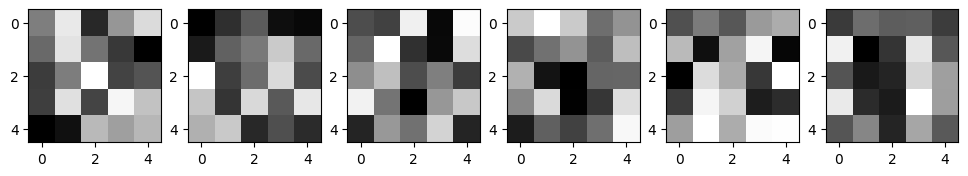

In [414]:
import matplotlib.pyplot as plt

_, axs = plt.subplots(1, len(first_kernels), figsize=(12, 12))
for img, ax in zip(first_kernels, axs):
    ax.imshow(img, cmap='gray')
plt.show()

Ahora nos traeremos una imagen al azar, y veremos el efecto de los kernels individualmente

In [133]:
def obtain_kernels(model):
  first_kernels = model.layer1[0].weight.data.cpu().numpy()
  first_kernels = [kernel[0] for kernel in first_kernels]
  second_kernels = model.layer2[0].weight.data.cpu().numpy()
  second_kernels = [kernel[0] for kernel in second_kernels]
  return [first_kernels, second_kernels]

In [134]:
def obtain_outputs(kernels, img):

  outputs = []
  for kernel in kernels:
    kernel = torch.tensor(kernel, dtype=torch.float32)
    kernel = kernel.unsqueeze(0).unsqueeze(0)
    outputs.append(F.conv2d(img, kernel, padding=1))

  return outputs

In [135]:
import matplotlib.pyplot as plt

# Obtener una imagen y su etiqueta del DataLoader
dataiter = iter(test_iterator)
images, labels = next(dataiter)

# Tomamos la primera imagen del batch
img = images[0].unsqueeze(0).to(device)  # Shape: [1,1,32,32]
label = labels[0]

kernels = obtain_kernels(model)

act1 = obtain_outputs(kernels[0], img)

# Asumimos que `img` es [1,1,H,W] y `act1` es [6,H,W]
fig = plt.figure(figsize=(12, 6))

# Subplot grande para la imagen original
ax_orig = plt.subplot2grid((2, 4), (0, 0), rowspan=2)
ax_orig.imshow(img.squeeze().cpu().numpy(), cmap='gray')
ax_orig.set_title("Imagen original")
ax_orig.axis('off')

# Subplots para las activaciones
for i in range(6):
    ax = plt.subplot2grid((2, 4), (i // 3, 1 + i % 3))
    ax.imshow(act1[i].squeeze().cpu().numpy(), cmap='gray')
    ax.set_title(f'Filtro {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()


NameError: name 'test_iterator' is not defined

In [44]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_trainable_parameters(model)

61750

In [6]:
import gdown
import numpy as np

file_id = "1URDQ0HoVC9IEGQxvjpqhPDDb0-_wwpa7"
url = f"https://drive.google.com/uc?id={file_id}"
output = "labels.pt"
gdown.download(url, output, quiet=False)

file_id = "1BdZ-ttOES9xGxs1zToPh0ReMtkcGONjN"
url = f"https://drive.google.com/uc?id={file_id}"
output = "dataset.pt"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1URDQ0HoVC9IEGQxvjpqhPDDb0-_wwpa7
To: /content/labels.pt
100%|██████████| 129k/129k [00:00<00:00, 3.57MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1BdZ-ttOES9xGxs1zToPh0ReMtkcGONjN
From (redirected): https://drive.google.com/uc?id=1BdZ-ttOES9xGxs1zToPh0ReMtkcGONjN&confirm=t&uuid=7d8bfcd3-3b6e-4534-8799-f2562bc864d5
To: /content/dataset.pt
100%|██████████| 524M/524M [00:04<00:00, 130MB/s]


'dataset.pt'

In [82]:
labels = torch.load("/content/labels.pt")
dataset = torch.load("/content/dataset.pt")

In [83]:
from torch.utils.data import Dataset

class TensorDataset(Dataset):
    def __init__(self, X, y, transform=None):
        assert len(X) == len(y)
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].float()
        if x.ndim == 2:
            x = x.unsqueeze(0)

        y = self.y[idx].long()

        if self.transform:
            x = self.transform(x)

        return x, y


In [84]:
from torchvision.transforms import ToPILImage, ToTensor

train_transforms = transforms.Compose([
                            #ToPILImage(),
                            transforms.RandomRotation(180, fill=(0,)),
                            transforms.RandomCrop(64, padding=4),
                            #ToTensor()
                                      ])

In [86]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [87]:
train_data = TensorDataset(dataset, labels, train_transforms)

In [88]:
from torch.utils.data import random_split

# Por ejemplo, 80% entrenamiento, 20% prueba
train_size = int(0.8 * len(train_data))
test_size = len(train_data) - train_size

train_data, test_data = random_split(train_data, [train_size, test_size])

In [89]:
def plot_images(images):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(dpi = 150)
    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1)
        ax.imshow(images[i].view(64, 64).cpu().numpy(), cmap='gray')
        ax.axis('off')

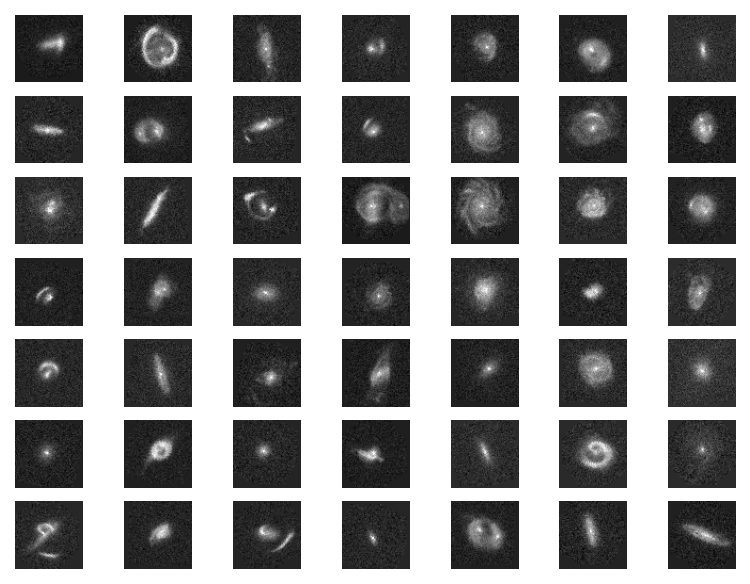

In [90]:
N_IMAGES = 50

images = [image for image, label in [train_data[i] for i in range(N_IMAGES)]]

plot_images(images)

In [146]:
import torch.utils.data as data

BATCH_SIZE = 512

train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)

# valid_iterator = data.DataLoader(valid_data,
#                                  batch_size=BATCH_SIZE)

valid_iterator = data.DataLoader(test_data,
                                batch_size=BATCH_SIZE)

In [148]:
len(train_iterator)

25

In [100]:
len(train_data)

12800

In [128]:
model = LeNet5(2, (64,64))
model.to(device)

LeNet5(
  (layer1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=2704, out_features=120, bias=True)
  (relu): ReLU()
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=84, out_features=2, bias=True)
)

In [129]:
#Para optimizar
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [130]:
EPOCHS = 15

best_valid_loss = float('inf')

for epoch in trange(EPOCHS):

    start_time = time.monotonic()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

  0%|          | 0/15 [00:00<?, ?it/s]

Training:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 35s
	Train Loss: 0.614 | Train Acc: 65.81%
	 Val. Loss: 0.691 |  Val. Acc: 49.05%


Training:   0%|          | 0/25 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 14 | Epoch Time: 0m 35s
	Train Loss: 0.269 | Train Acc: 88.79%
	 Val. Loss: 0.259 |  Val. Acc: 89.09%


Training:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 15 | Epoch Time: 0m 38s
	Train Loss: 0.266 | Train Acc: 89.02%
	 Val. Loss: 0.262 |  Val. Acc: 89.48%


In [131]:
# Test the model
# In the test phase, we don't need to compute gradients (for memory efficiency)

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in valid_iterator:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the 3200 test images: {accuracy:.2f} %')

Accuracy of the network on the 3200 test images: 89.59 %


Revisemos ahora los kernels

In [136]:
kernels = obtain_kernels(model)
kernels

[[array([[ 0.07701402,  0.09283061,  0.18548459,  0.01110598, -0.18085767],
         [-0.1353746 , -0.03655017, -0.00296373,  0.11284688, -0.07986458],
         [-0.14506827, -0.05668097, -0.01604144,  0.1704153 ,  0.01354784],
         [-0.06638131, -0.0200426 , -0.07396161, -0.13966523, -0.15716106],
         [ 0.04397444,  0.0957426 ,  0.08470871,  0.19511196, -0.15102428]],
        dtype=float32),
  array([[-0.1313587 ,  0.1322507 , -0.14520359, -0.13714026,  0.0259879 ],
         [-0.12968107,  0.08147263, -0.1860292 , -0.0971729 ,  0.01695266],
         [ 0.12158716, -0.05849907, -0.10171665, -0.13713871,  0.08351909],
         [-0.13788608, -0.00225285, -0.05286857,  0.1593644 ,  0.03387553],
         [-0.11267309,  0.01632325, -0.14873923, -0.1059008 , -0.05609406]],
        dtype=float32),
  array([[ 0.16276036,  0.12715767,  0.17339465,  0.07220019,  0.06775559],
         [-0.07248883,  0.08822065, -0.03736566,  0.03310283,  0.1477413 ],
         [-0.13093476, -0.0608973 , -0

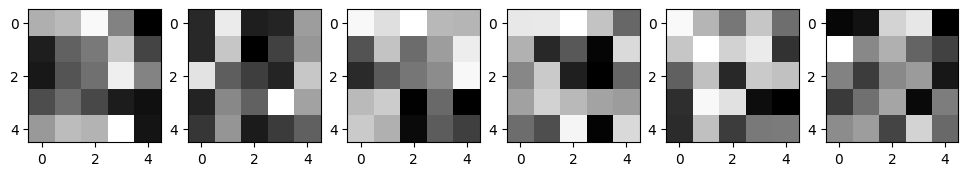

In [139]:
import matplotlib.pyplot as plt

_, axs = plt.subplots(1, len(kernels[0]), figsize=(12, 12))
for img, ax in zip(kernels[0], axs):
    ax.imshow(img, cmap='gray')
plt.show()

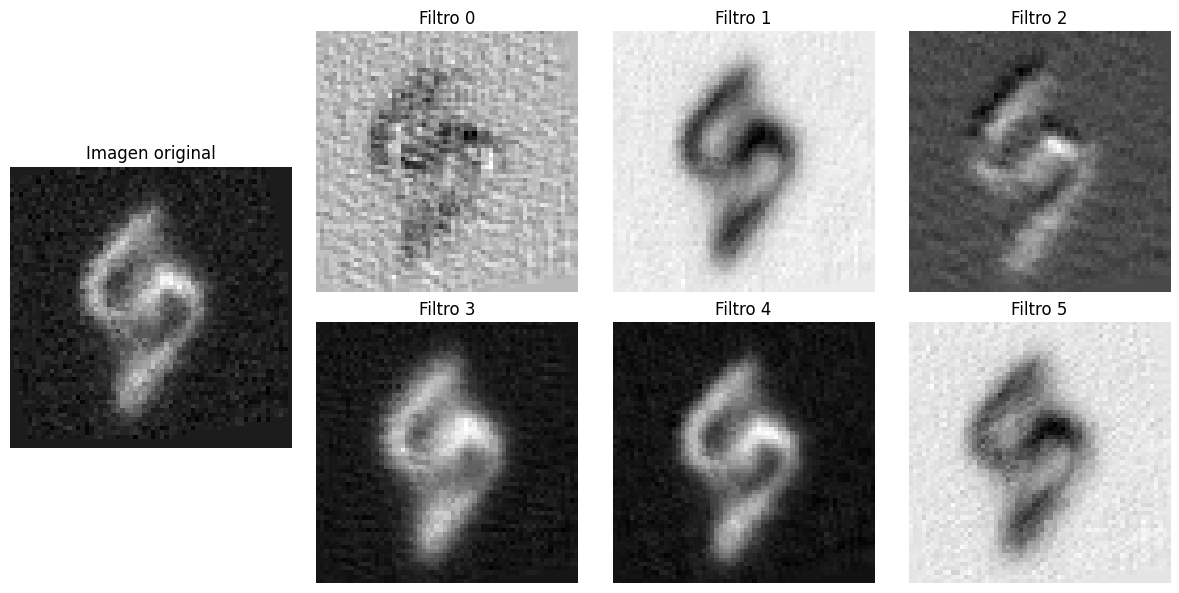

In [151]:
import matplotlib.pyplot as plt

# Obtener una imagen y su etiqueta del DataLoader
dataiter = iter(valid_iterator)
images, labels = next(dataiter)

# Tomamos la primera imagen del batch
img = images[1].unsqueeze(0).to(device)  # Shape: [1,1,32,32]
label = labels[0]

kernels = obtain_kernels(model)

act1 = obtain_outputs(kernels[0], img)

# Asumimos que `img` es [1,1,H,W] y `act1` es [6,H,W]
fig = plt.figure(figsize=(12, 6))

# Subplot grande para la imagen original
ax_orig = plt.subplot2grid((2, 4), (0, 0), rowspan=2)
ax_orig.imshow(img.squeeze().cpu().numpy(), cmap='gray')
ax_orig.set_title("Imagen original")
ax_orig.axis('off')

# Subplots para las activaciones
for i in range(6):
    ax = plt.subplot2grid((2, 4), (i // 3, 1 + i % 3))
    ax.imshow(act1[i].squeeze().cpu().numpy(), cmap='gray')
    ax.set_title(f'Filtro {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()
